<a href="https://colab.research.google.com/github/ekanshkhare00000/PERCEPTRON/blob/main/Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN, Embedding,Flatten

In [14]:
(x_train,y_train),(x_test,y_test)= imdb.load_data(num_words=10000)

In [15]:
x_train = pad_sequences(x_train, padding = 'post',maxlen = 50)
x_test = pad_sequences(x_test,padding = 'post',maxlen=50)

In [16]:
x_train.shape

(25000, 50)

In [17]:
model = Sequential()
model.add(Embedding(input_dim = 10000, output_dim=2,input_length =50))
model.add (SimpleRNN(32,return_sequences = False))
model.add(Dense(1,activation = 'sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])
history = model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - acc: 0.5482 - loss: 0.6795 - val_acc: 0.5987 - val_loss: 0.6718
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - acc: 0.7913 - loss: 0.4501 - val_acc: 0.7896 - val_loss: 0.4808
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - acc: 0.8562 - loss: 0.3426 - val_acc: 0.7998 - val_loss: 0.4359
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - acc: 0.8826 - loss: 0.2924 - val_acc: 0.8022 - val_loss: 0.4501
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - acc: 0.8991 - loss: 0.2563 - val_acc: 0.7910 - val_loss: 0.4998


In [20]:
y_pred = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [22]:
y_pred_labels = (y_pred>0.5).astype(int)

In [23]:
for i in range(5):
  print('predicted:', y_pred_labels[i],'actual:',y_test[i])

predicted: [0] actual: 0
predicted: [1] actual: 1
predicted: [1] actual: 1
predicted: [0] actual: 0
predicted: [1] actual: 1


[[10839  1661]
 [ 3564  8936]]


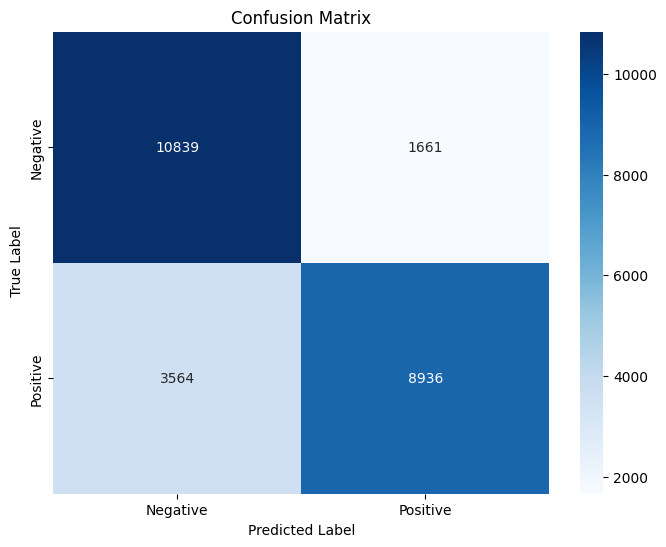

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test,y_pred_labels)
print(cm)
plt.figure(figsize=(8,6))
ax = sns.heatmap(cm, annot = True, fmt ='d', cmap = 'Blues',
                 xticklabels = ['Negative','Positive'],
                 yticklabels = ['Negative','Positive'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel(' True Label')
ax.set_title('Confusion Matrix')
plt.show()



In [31]:
text = [' music was good story narration was excellent and acting was overating']
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(text)
seq = tokenizer.texts_to_sequences(text)
padded = pad_sequences(seq,padding = 'post', maxlen=50)
prediction = model.predict(padded)
if prediction >0.5:
  print('positive review')
else:
  print('negative review')
print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
positive review

